# Compute Field Potentials

In this notebook we continue the Hagen-model workflow by using the simulated spike trains from Tutorial 1 (`Simulate a LIF Network`) for `J_ext = 28, 30, 32` nA.

We will:
- load spike data from the LIF tutorial sweep where `J_ext` changes (`28, 30, 32` nA),
- compute CDMs using a biophysical kernel that captures properties of the equivalent multicompartment network,
- compute a simple firing-rate proxy from the same spike trains,
- compare outputs from the kernel-based CDM and firing-rate proxy in the time domain and in the spectrum.

## Requirements

To run this notebook, install:
- `ncpi`
- `nest-simulator` (to regenerate spikes if needed)
- `neuron`, `LFPy`, `lfpykernels`, `h5py` (for kernel/CDM workflow)

You also need the multicompartment reference data available locally at:
- `/home/pablomc/Downloads/multicompartment_neuron_network`

### 1) Set up paths, imports, and reusable helpers

This cell imports dependencies, locates the repository folders, and defines helper functions for spike-rate computation, normalization, and spectrum normalization.

In [1]:
import os
import sys
import pickle
from pathlib import Path

import numpy as np
import scipy.signal as ss
import matplotlib.pyplot as plt

import ncpi


def find_repo_root(start_dir: Path) -> Path:
    for candidate in [start_dir, *start_dir.parents]:
        if (candidate / "examples" / "simulation" / "Hagen_model" / "simulation").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing examples/simulation/Hagen_model/simulation")


def get_spike_rate(times, transient, dt, tstop):
    bins = np.arange(transient, tstop + dt, dt)
    hist, _ = np.histogram(times, bins=bins)
    return bins, hist.astype(float)


def zscore_signal(x):
    x = np.asarray(x, dtype=float)
    mu = np.mean(x)
    sigma = np.std(x)
    if sigma == 0:
        return x - mu
    return (x - mu) / sigma


def normalized_psd(signal, fs, freq_range=(20.0, 200.0)):
    signal = np.asarray(signal, dtype=float)
    nperseg = min(4096, max(256, len(signal)))
    f, pxx = ss.welch(signal, fs=fs, nperseg=nperseg)
    mask = (f >= freq_range[0]) & (f <= freq_range[1])
    f_sel = f[mask]
    p_sel = pxx[mask]
    s = np.sum(p_sel)
    if s > 0:
        p_sel = p_sel / s
    return f_sel, p_sel


REPO_ROOT = find_repo_root(Path.cwd().resolve())
HAGEN_SIM_ROOT = REPO_ROOT / "examples" / "simulation" / "Hagen_model" / "simulation"
PARAM_FOLDER = HAGEN_SIM_ROOT / "params"
PYTHON_FOLDER = HAGEN_SIM_ROOT / "python"
OUTPUT_FOLDER = HAGEN_SIM_ROOT / "output"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

if str(PARAM_FOLDER) not in sys.path:
    sys.path.insert(0, str(PARAM_FOLDER))

from analysis_params import KernelParams

print(f"Repo root: {REPO_ROOT}")
print(f"Simulation root: {HAGEN_SIM_ROOT}")

Repo root: /home/pablomc/OneDrive/2026/ncpi
Simulation root: /home/pablomc/OneDrive/2026/ncpi/examples/simulation/Hagen_model/simulation


### 2) Load spike sweeps from Tutorial 1

This cell loads spike data generated in the LIF tutorial (`J_ext = 28, 30, 32`) directly from:
- `/home/pablomc/OneDrive/2026/ncpi/examples/simulation/Hagen_model/simulation/output/`

No simulation is performed here. If the folder or required sweep file is missing, the notebook raises an error.

In [2]:
SPIKE_SWEEP_FILE = OUTPUT_FOLDER / "tutorial_lif_spike_sweep.pkl"

if not OUTPUT_FOLDER.exists():
    raise FileNotFoundError(
        f"LIF simulation output folder not found: {OUTPUT_FOLDER}"
    )

if not SPIKE_SWEEP_FILE.exists():
    raise FileNotFoundError(
        f"Required sweep file not found: {SPIKE_SWEEP_FILE}. "
        "Run the LIF tutorial first and save the sweep results to this file."
    )

with open(SPIKE_SWEEP_FILE, "rb") as handle:
    spike_payload = pickle.load(handle)

spike_records = spike_payload["records"]
available_jext = [float(r["J_ext"]) for r in spike_records]
print("Loaded J_ext values:", available_jext)
print("LIF output folder:", OUTPUT_FOLDER)
print("Loaded sweep file:", SPIKE_SWEEP_FILE)

Loaded J_ext values: [28.0, 30.0, 32.0]
LIF output folder: /home/pablomc/OneDrive/2026/ncpi/examples/simulation/Hagen_model/simulation/output
Loaded sweep file: /home/pablomc/OneDrive/2026/ncpi/examples/simulation/Hagen_model/simulation/output/tutorial_lif_spike_sweep.pkl


### 3) Configure multicompartment reference data for kernel computation

The kernel-based method requires the multicompartment network files and its precomputed outputs, loaded directly from a local folder path.

In [3]:
MC_FOLDER = Path("/home/pablomc/Downloads/multicompartment_neuron_network")

# (1) simulation output from the multicompartment neuron network model
OUTPUT_SIM_PATH = MC_FOLDER / "output" / "adb947bfb931a5a8d09ad078a6d256b0"

if not MC_FOLDER.exists():
    raise FileNotFoundError(
        f"Multicompartment folder not found: {MC_FOLDER}."
    )
if not OUTPUT_SIM_PATH.exists():
    raise FileNotFoundError(
        f"Multicompartment output path not found: {OUTPUT_SIM_PATH}."
    )

print("MC folder:", MC_FOLDER)
print("MC output path:", OUTPUT_SIM_PATH)

MC folder: /home/pablomc/Downloads/multicompartment_neuron_network
MC output path: /home/pablomc/Downloads/multicompartment_neuron_network/output/adb947bfb931a5a8d09ad078a6d256b0


### 4) Create kernels

This cell creates CDM kernels using `FieldPotential.create_kernel` and the same biophysics used in the Hagen pipeline (`set_Ih_linearized_hay2011`, `make_cell_uniform`).

In [4]:
dt_ref = float(spike_records[0]["dt"])
tstop_ref = float(spike_records[0]["tstop"])

fp = ncpi.FieldPotential()
biophys = ["set_Ih_linearized_hay2011", "make_cell_uniform"]

H_YX = fp.create_kernel(
    str(MC_FOLDER),
    KernelParams,
    biophys,
    dt_ref,
    tstop_ref,
    output_sim_path=str(OUTPUT_SIM_PATH),
    electrodeParameters=None,
    CDM=True,
)

print("Kernel keys:", sorted(H_YX.keys()))

Kernel keys: ['E:E', 'E:I', 'I:E', 'I:I']


### 5) Compute CDMs, firing-rate proxies, and normalized spectra for each `J_ext`

For each spike dataset we compute:
- total CDM signal from kernel convolution,
- two firing-based proxies (`FR_E` and `FR_EI_mean`),
- z-score normalized versions of all signals,
- normalized power spectra in the same frequency range.

CDMs and proxies are decimated with the same factor, then each signal is z-scored so the comparison focuses on dynamics (shape and timing) rather than absolute amplitude.

This step also exports a CDM-only sweep file for Tutorial 3 (`Feature Extraction`).


In [5]:
DECIM_Q = 10
PROBE_NAME = "KernelApproxCurrentDipoleMoment"
FREQ_RANGE = (20.0, 200.0)

analysis_results = []

for record in spike_records:
    j_ext = float(record["J_ext"])
    dt = float(record["dt"])
    tstop = float(record["tstop"])
    transient = float(record["transient"])
    populations = record["populations"]
    times = record["times"]

    cdm_by_pair = fp.compute_cdm_lfp_from_kernels(
        H_YX,
        spike_times=times,
        dt=dt,
        tstop=tstop,
        transient=transient,
        probe=PROBE_NAME,
        component=2,
        mode="same",
        scale=dt / 1000.0,
    )

    total_cdm = np.zeros_like(next(iter(cdm_by_pair.values())))
    for value in cdm_by_pair.values():
        total_cdm = total_cdm + value

    bins, rate_e = get_spike_rate(times["E"], transient, dt, tstop)
    _, rate_i = get_spike_rate(times["I"], transient, dt, tstop)

    proxy_fr_e = fp.compute_proxy(
        method="FR",
        sim_data={"FR": rate_e.reshape(1, -1)},
        sim_step=None,
    )
    proxy_fr_ei = fp.compute_proxy(
        method="FR",
        sim_data={"FR": np.vstack([rate_e, rate_i])},
        sim_step=None,
    )

    cdm_dec = ss.decimate(total_cdm, q=DECIM_Q, zero_phase=True)
    p_e_dec = ss.decimate(proxy_fr_e, q=DECIM_Q, zero_phase=True)
    p_ei_dec = ss.decimate(proxy_fr_ei, q=DECIM_Q, zero_phase=True)

    min_len = min(len(cdm_dec), len(p_e_dec), len(p_ei_dec))
    cdm_dec = cdm_dec[:min_len]
    p_e_dec = p_e_dec[:min_len]
    p_ei_dec = p_ei_dec[:min_len]

    time_bins = np.arange(transient, tstop, dt)[::DECIM_Q][:min_len]

    cdm_norm = zscore_signal(cdm_dec)
    p_e_norm = zscore_signal(p_e_dec)
    p_ei_norm = zscore_signal(p_ei_dec)

    fs_dec = 1000.0 / (DECIM_Q * dt)
    f_cdm, psd_cdm = normalized_psd(cdm_norm, fs=fs_dec, freq_range=FREQ_RANGE)
    f_pe, psd_pe = normalized_psd(p_e_norm, fs=fs_dec, freq_range=FREQ_RANGE)
    f_pei, psd_pei = normalized_psd(p_ei_norm, fs=fs_dec, freq_range=FREQ_RANGE)

    analysis_results.append(
        {
            "J_ext": j_ext,
            "time_bins": time_bins,
            "cdm_norm": cdm_norm,
            "proxy_fr_e_norm": p_e_norm,
            "proxy_fr_ei_norm": p_ei_norm,
            "f_cdm": f_cdm,
            "psd_cdm": psd_cdm,
            "f_proxy_e": f_pe,
            "psd_proxy_e": psd_pe,
            "f_proxy_ei": f_pei,
            "psd_proxy_ei": psd_pei,
            "fs_hz": fs_dec,
            "dt": dt,
            "decimation_q": DECIM_Q,
        }
    )

print("Computed field potentials for J_ext:", [r["J_ext"] for r in analysis_results])

CDM_SWEEP_FILE = OUTPUT_FOLDER / "tutorial_cdm_sweep.pkl"

cdm_records = []
for result in analysis_results:
    cdm_records.append(
        {
            "J_ext": float(result["J_ext"]),
            "time_bins": np.asarray(result["time_bins"], dtype=float),
            "cdm": np.asarray(result["cdm_norm"], dtype=float),
            "fs_hz": float(result["fs_hz"]),
            "dt": float(result["dt"]),
            "decimation_q": int(result["decimation_q"]),
        }
    )

with open(CDM_SWEEP_FILE, "wb") as handle:
    pickle.dump({"records": cdm_records}, handle)

print("Saved CDM sweep file:", CDM_SWEEP_FILE)


Computed field potentials for J_ext: [28.0, 30.0, 32.0]
Saved CDM sweep file: /home/pablomc/OneDrive/2026/ncpi/examples/simulation/Hagen_model/simulation/output/tutorial_cdm_sweep.pkl


### 6) Compare normalized CDMs and proxies in time domain

Each panel corresponds to one `J_ext` value and overlays normalized CDM and firing-based proxies over the same time window.

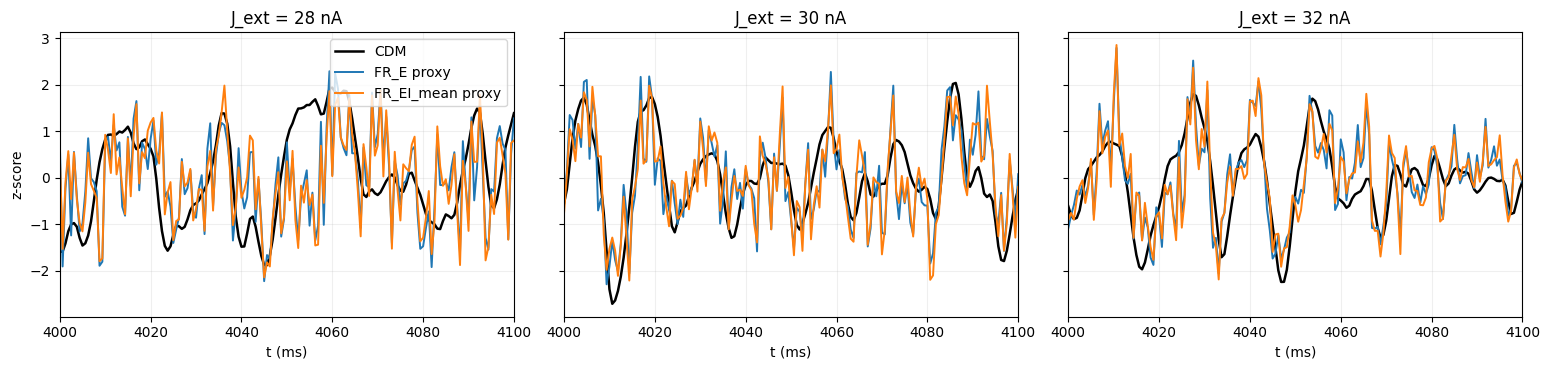

In [6]:
T_WINDOW = (4000.0, 4100.0)
fig, axes = plt.subplots(1, len(analysis_results), figsize=(5.2 * len(analysis_results), 3.8), sharey=True)
if len(analysis_results) == 1:
    axes = [axes]

for col, (ax, result) in enumerate(zip(axes, analysis_results)):
    t = result["time_bins"]
    mask = (t >= T_WINDOW[0]) & (t <= T_WINDOW[1])

    ax.plot(t[mask], result["cdm_norm"][mask], color="k", lw=1.8, label="CDM" if col == 0 else None)
    ax.plot(t[mask], result["proxy_fr_e_norm"][mask], color="C0", lw=1.4, label="FR_E proxy" if col == 0 else None)
    ax.plot(t[mask], result["proxy_fr_ei_norm"][mask], color="C1", lw=1.4, label="FR_EI_mean proxy" if col == 0 else None)

    ax.set_title(f"J_ext = {result['J_ext']:.0f} nA")
    ax.set_xlabel("t (ms)")
    ax.set_xlim(T_WINDOW)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("z-score")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

### 7) Compare normalized spectra of CDMs and proxies

This plot shows normalized Welch spectra for CDM and firing-based proxies in each `J_ext` condition.

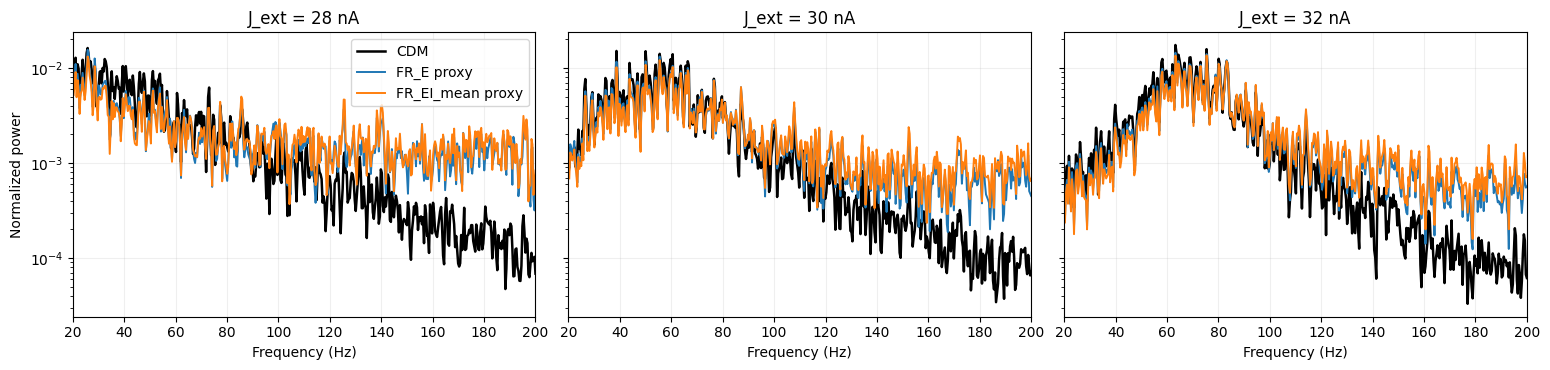

In [7]:
fig, axes = plt.subplots(1, len(analysis_results), figsize=(5.2 * len(analysis_results), 3.8), sharey=True)
if len(analysis_results) == 1:
    axes = [axes]

for col, (ax, result) in enumerate(zip(axes, analysis_results)):
    ax.semilogy(result["f_cdm"], result["psd_cdm"], color="k", lw=1.8, label="CDM" if col == 0 else None)
    ax.semilogy(result["f_proxy_e"], result["psd_proxy_e"], color="C0", lw=1.4, label="FR_E proxy" if col == 0 else None)
    ax.semilogy(result["f_proxy_ei"], result["psd_proxy_ei"], color="C1", lw=1.4, label="FR_EI_mean proxy" if col == 0 else None)

    ax.set_title(f"J_ext = {result['J_ext']:.0f} nA")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_xlim(FREQ_RANGE)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("Normalized power")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()